In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

pd.set_option('display.max_columns', None)

In [3]:
raw = fetch_ucirepo(id=601)

X = raw.data.features
y = raw.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10000, 12)

Columns: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data types:
 Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object

Missing values:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64


In [6]:
print("Failure distribution:")
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean()*100:.2f}%")

Failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [7]:
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
df.rename(columns={
    'Air_temperature_K': 'air_temp',
    'Process_temperature_K': 'process_temp',
    'Rotational_speed_rpm': 'rot_speed',
    'Torque_Nm': 'torque',
    'Tool_wear_min': 'tool_wear',
    'Machine_failure': 'failure'
}, inplace=True)

df.head()

,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
print(df.columns.tolist())

['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [11]:
# Drop ID columns — use errors='ignore' in case names differ
df.drop(columns=[col for col in df.columns if 'UDI' in col or 'Product' in col], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [12]:
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
df['Type'].value_counts()

Type
0    6000
1    2997
2    1003
Name: count, dtype: int64

In [17]:
# Temperature differential — key indicator of heat dissipation failure
df['temp_diff'] = df['Process_temperature'] - df['Air_temperature']

# Power — physics: Power (W) = Torque (Nm) × Angular velocity (rad/s)
df['power'] = df['Torque'] * (df['Rotational_speed'] * 2 * np.pi / 60)

# Wear rate — torque stress over tool life
df['wear_rate'] = df['Tool_wear'] * df['Torque']

# Tool wear severity flag — domain rule: >200 min is high risk
df['high_wear'] = (df['Tool_wear'] > 200).astype(int)

df[['temp_diff', 'power', 'wear_rate', 'high_wear']].describe()

,temp_diff,power,wear_rate,high_wear
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550,0.076200
std,1.001094,1067.418295,2826.567692,0.265331
min,7.600000,1148.440610,0.000000,0.000000
25%,9.300000,5561.184484,1963.650000,0.000000
50%,9.800000,6271.027344,4012.950000,0.000000
75%,11.000000,7003.002724,6279.000000,0.000000
max,12.100000,10469.923005,16497.000000,1.000000


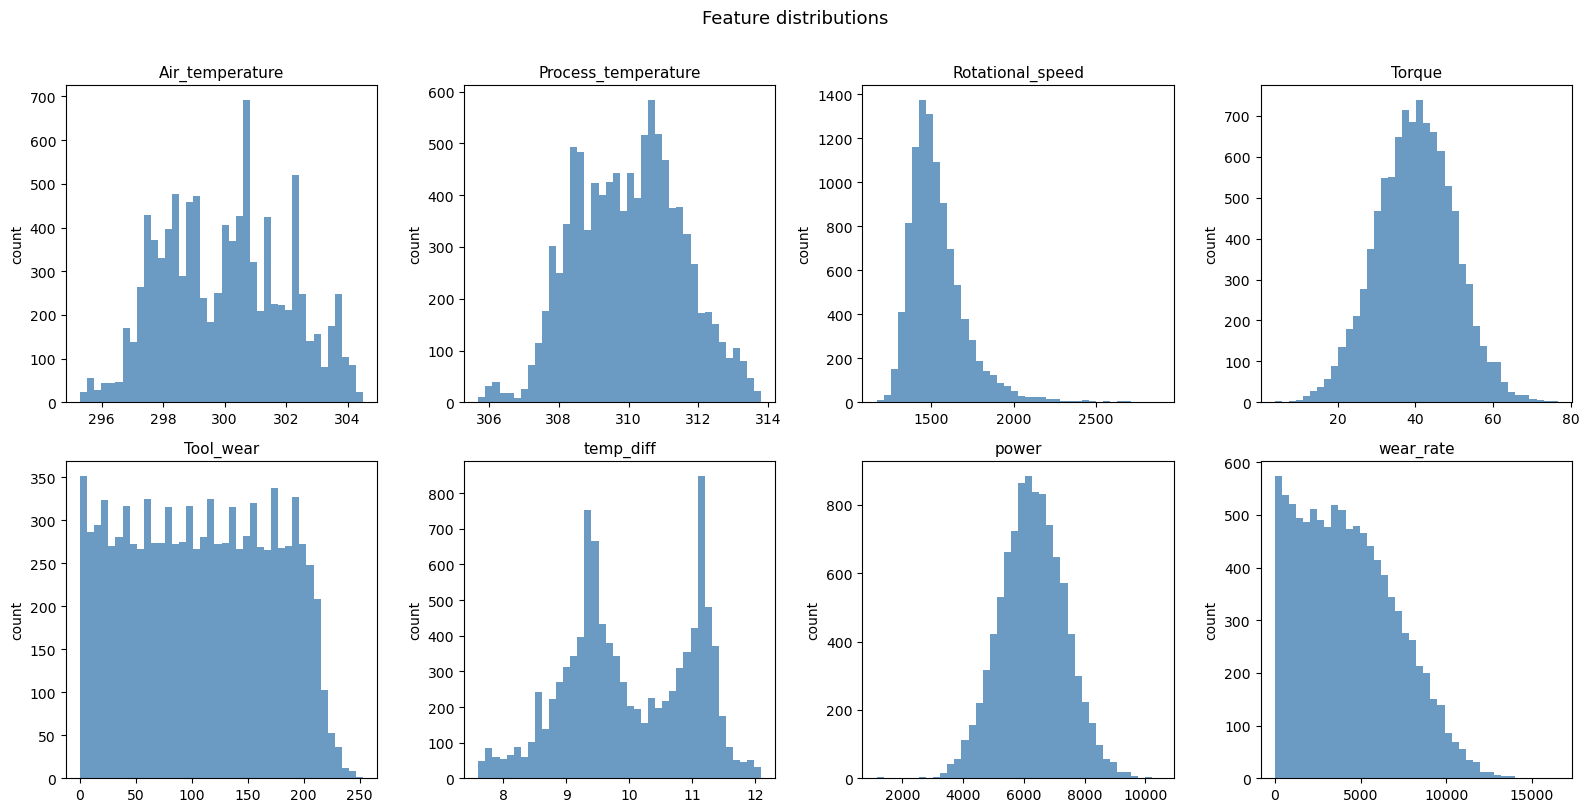

In [21]:
features = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear',
            'temp_diff', 'power', 'wear_rate']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_ylabel('count')

plt.suptitle('Feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

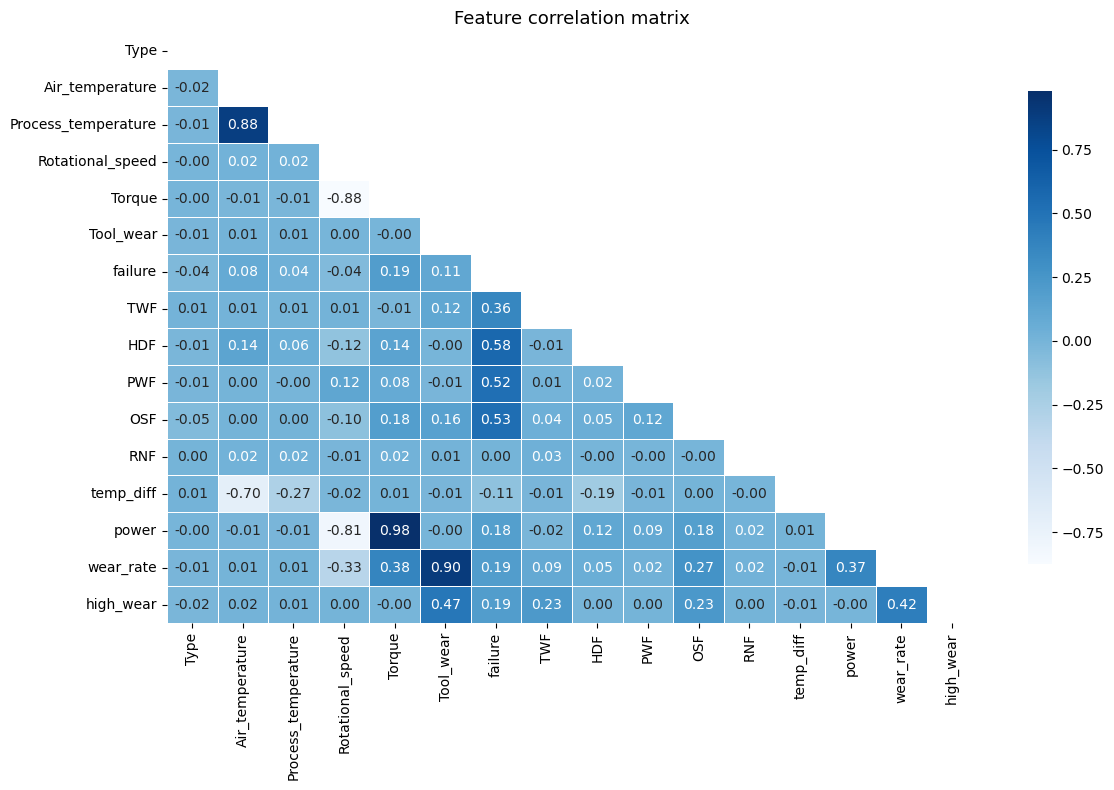

In [22]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
print("Final dataset shape:", df.shape)
print("\nFailure distribution:")
print(df['failure'].value_counts())
print(f"\nClass imbalance ratio: {df['failure'].value_counts()[0] / df['failure'].value_counts()[1]:.1f}:1")

Final dataset shape: (10000, 16)

Failure distribution:
failure
0    9661
1     339
Name: count, dtype: int64

Class imbalance ratio: 28.5:1


In [24]:
df.to_csv('ai4i_cleaned.csv', index=False)
print("Saved → ai4i_cleaned.csv")
print("Columns ready for modeling:", df.columns.tolist())

Saved → ai4i_cleaned.csv
Columns ready for modeling: ['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_diff', 'power', 'wear_rate', 'high_wear']
